# LLM Workshop Code Along

This notebook mirrors `presentation.qmd` and gives runnable demos for each section.

## Agenda

1. LLM Foundations\n
2. RAG\n
3. LLM Evals\n
4. LLM Agents\n
5. MCP and App Patterns

In [1]:
# Uncomment and run this cell on Google Colab to install all required packages
# !pip install -q tiktoken sentence-transformers numpy pandas \
#   langchain langchain-community langchain-huggingface langchain-openai langchain-core \
#   langgraph transformers accelerate

In [2]:
import os
import re
import json
import math
import random
import sqlite3
import statistics
from collections import Counter
from typing import TypedDict, Annotated, List

import tiktoken
import numpy as np
import pandas as pd
from langchain_core.messages import HumanMessage, AnyMessage
from langgraph.graph.message import add_messages
from openai import OpenAI

random.seed(42)

## LLM Foundations: Tokenization

In [3]:
enc = tiktoken.encoding_for_model("gpt-2")

sample = "NotebookLM is a RAG app for source-grounded Q&A."
tokens = enc.encode(sample)

print(tokens)
print("Token count:", len(tokens))
print("Decoded tokens:", [enc.decode([t]) for t in tokens])

[6425, 2070, 31288, 318, 257, 371, 4760, 598, 329, 2723, 12, 2833, 276, 1195, 5, 32, 13]
Token count: 17
Decoded tokens: ['Note', 'book', 'LM', ' is', ' a', ' R', 'AG', ' app', ' for', ' source', '-', 'ground', 'ed', ' Q', '&', 'A', '.']


## LLM Foundations: Vector embeddings

In [4]:
# !pip install -q sentence-transformers

In [5]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9117.47it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
embeddings = model.encode("Miami Universoty of Ohio")
print(embeddings[:10])
print(embeddings.shape)  

[ 0.02065466 -0.03984684 -0.02121316  0.0223866   0.01308369 -0.03353535
 -0.03918867 -0.0909925  -0.03492295  0.04086898]
(384,)


### Euclidean Distance

$$
d(\mathbf{a}, \mathbf{b}) = \|\mathbf{a} - \mathbf{b}\| = \sqrt{\sum_{i=1}^{n}(a_i - b_i)^2}
$$

### Cosine Similarity

$$
\text{cos}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \, \|\mathbf{b}\|} = \frac{\sum_{i=1}^{n} a_i b_i}{\sqrt{\sum_{i=1}^{n} a_i^2} \; \sqrt{\sum_{i=1}^{n} b_i^2}}
$$

### Comparison

| | Euclidean Distance | Cosine Similarity |
|---|---|---|
| **Measures** | Magnitude of separation in space | Angular similarity of direction |
| **Range** | $[0, \infty)$ | $[-1, 1]$ |
| **Identical vectors** | $0$ | $1$ |
| **Orthogonal vectors** | $\sqrt{\|\mathbf{a}\|^2 + \|\mathbf{b}\|^2}$ | $0$ |
| **Scale-invariant** | No | Yes |
| **Best for** | Clustering, k-NN | Retrieval, semantic search |



> cosine gives more spread between similar items, while Euclidean gives more spread between dissimilar items. 





In [33]:
def euclidean_distance(a, b):
    return np.linalg.norm(np.array(a) - np.array(b))

def cosine_similarity(a, b):
    a, b = np.array(a), np.array(b)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [34]:
texts = [
    "emergency stop procedure for CNC lathe",
    "how to halt the CNC machine in an emergency",
    "the weather in Ohio today",
]

embs = model.encode(texts)

for i in range(len(texts)):
    for j in range(i + 1, len(texts)):
        print(f"\n'{texts[i]}' vs '{texts[j]}'")
        print(f"  Cosine Similarity:   {cosine_similarity(embs[i], embs[j]):.4f}")
        print(f"  Euclidean Distance:  {euclidean_distance(embs[i], embs[j]):.4f}")


'emergency stop procedure for CNC lathe' vs 'how to halt the CNC machine in an emergency'
  Cosine Similarity:   0.5908
  Euclidean Distance:  0.9047

'emergency stop procedure for CNC lathe' vs 'the weather in Ohio today'
  Cosine Similarity:   -0.0166
  Euclidean Distance:  1.4259

'how to halt the CNC machine in an emergency' vs 'the weather in Ohio today'
  Cosine Similarity:   0.0377
  Euclidean Distance:  1.3873


## LLM Foundations: `temperature`

Higher temp = more random

If your logits are [2, 1, 0.5], dividing by 0.1 gives [20, 10, 5]. Now the differences are huge, so softmax pushes almost all probability onto the top token — the distribution becomes skewed, aka the model is way more confidentt. 

$$
\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}
$$

In [35]:
logits = np.array([2.0, 1.0, 0.5])
labels = ["A", "B", "C"]

def softmax(logits):
    scaled = logits 
    exp = np.exp(scaled - scaled.max())
    return np.round(exp / exp.sum(), 2)

temps = [0.1, 0.5, 1.0, 2.0]

print(softmax(logits/1.2)) # raw probabilits 
print(softmax(logits/0.3)) # low temp -> more determinisitc/less random
print(softmax(logits/10)) # high temp -> less determinisitc/more random

[0.58 0.25 0.17]
[0.96 0.03 0.01]
[0.36 0.33 0.31]


# Open AI API

In [36]:
api_key = os.getenv('OPENAI_API_KEY')
if not api_key:
    print('Set OPENAI_API_KEY to run a live model call.')


client = OpenAI(api_key=api_key)
response = client.responses.create(
    model='gpt-5-nano-2025-08-07',
    input='Summarize why grounding matters in RAG in 2 bullets.',
)
print(response.output_text)

- Ensures factual accuracy and timeliness by grounding responses in retrieved documents rather than relying on the model’s internal priors.

- Increases trust and verifiability by providing traceable sources, reducing hallucinations, and enabling easier auditing—especially in domain-specific tasks.


### Embedding Example (Langchain)

In [37]:
from langchain_openai import OpenAIEmbeddings
embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")
response = embedding_model.embed_query("Ryan Singh is awesome")
print(response[:10])

[-0.00650787353515625, 0.042755126953125, -0.0665283203125, -0.01708984375, -0.021026611328125, -0.03765869140625, 0.0244903564453125, 0.038360595703125, -0.00345611572265625, -0.03118896484375]


### Embedding Example (Native OpenAI)

In [38]:
from openai import OpenAI

client = OpenAI()

response = client.embeddings.create(
    model="text-embedding-3-small",
    input="Ryan Singh is awesome"
)

embedding = response.data[0].embedding
print(len(embedding))
print(embedding[:10])

1536
[-0.00650787353515625, 0.042755126953125, -0.0665283203125, -0.01708984375, -0.021026611328125, -0.03765869140625, 0.0244903564453125, 0.038360595703125, -0.00345611572265625, -0.03118896484375]


# Retrival Augmented Generation

I love art and this project started from a small idea of making art accessible. The problem was that RCCAM(Richard and Carole Cocks Art Museum) used a outdated SQL-based system to find artwork. When a curator goes in, they have to input exact SQL statements to find the artwork, the issue is that, the object in the system may not be tagged properly or not have all infomation in the system. My primary goal was to make a natural language retrival possible. 

## Creating a vector store 

In [7]:
EMBEDDINGS_DIRECTORY = './vstore'
import json
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document

from langchain_nomic.embeddings import NomicEmbeddings
from langchain_openai import OpenAIEmbeddings

with open("data/extracted_data.json") as file:
    data = json.load(file)

In [8]:
use_openai = True
if use_openai:
    embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")
else:
    embedding_model = NomicEmbeddings(model="nomic-embed-text-v1.5", inference_mode="local")

docs = []
for art in data:
    page_content = (
        f"Title: {art.get('Title', 'Unknown')}\n"
        f"Creator: {art.get('Creator', 'Unknown')}\n"
        f"Date: {art.get('Date', 'Unknown')}\n"
        f"Medium: {art.get('Medium', 'Unknown')}\n"
        f"Format: {art.get('Format', 'Unknown')}\n"
        f"Subject: {art.get('Subject', 'Unknown')}\n"
        f"Description: {art.get('Description', 'No description provided.')}\n"
        f"Tags: {', '.join(art.get('Tags', []))}\n"
    )
    metadata = {
        "id": art.get("Identifier"),
        "title": art.get("Title"),
        "creator": art.get("Creator"),
        "date": art.get("Date"),
        "medium": art.get("Medium"),
        "format": art.get("Format"),
        "subject": art.get("Subject"),
        "donor": art.get("Donor"),
        "citation": art.get("Citation"),
        "tags": art.get("Tags", []),
        "collection_link": art.get("Collection Link", None),
    }
    docs.append(Document(page_content=page_content, metadata=metadata))

# vectorstore = FAISS.from_documents(documents=docs, embedding=embedding_model)
# vectorstore.save_local(EMBEDDINGS_DIRECTORY)
# print(f"Vector store created and saved to {EMBEDDINGS_DIRECTORY}")

## Loading the Vector Store 

In [9]:
vectorstore = FAISS.load_local(
  EMBEDDINGS_DIRECTORY, 
  embeddings = embedding_model, 
  allow_dangerous_deserialization = True
  )
retriever = vectorstore.as_retriever(search_kwargs={"k": 10})

In [10]:
docs = retriever.invoke("Paul Cadmus") # example of using retriever as a node in LangGraph
for doc in docs:
    print(doc.metadata)

{'id': '2009.13', 'title': 'The Guitarist', 'creator': 'Paul Cadmus', 'date': '1969', 'medium': None, 'format': 'Painting', 'subject': 'Modern & Contemporary-Paintings-20th C. & Later', 'donor': 'Bequest of Robert E. White, Jr.', 'citation': 'Paul Cadmus, “The Guitarist,”Richard and Carole Cocks Art Museum at Miami University, accessed July 6, 2025,https://miamiuniversityartmuseum.omeka.net/items/show/1969.', 'tags': [], 'collection_link': 'https://miamiuniversityartmuseum.omeka.net/items/show/1969'}
{'id': '2015.2.32', 'title': 'Buckle plaque with standing man and cart', 'creator': None, 'date': '200-100 BCE', 'medium': None, 'format': 'Bronze', 'subject': 'Ancient & Classical', 'donor': None, 'citation': '“Buckle plaque with standing man and cart,”Richard and Carole Cocks Art Museum at Miami University, accessed July 6, 2025,https://miamiuniversityartmuseum.omeka.net/items/show/1145.', 'tags': [], 'collection_link': 'https://miamiuniversityartmuseum.omeka.net/items/show/1145'}
{'id':

## Setting an LLM 

This is what makes langchain/langgraph useful. We can easily switch out llm's very easily. 

In [11]:
from langgraph.graph import START, END, StateGraph

# ── Choose your model ──────────────────────────────────────────────────────────
# Options: "openai", "ollama", "local"
MODEL_PROVIDER = "ollama"

if MODEL_PROVIDER == "openai":
    from langchain_openai import ChatOpenAI
    llm = ChatOpenAI(model="gpt-4o-mini")

elif MODEL_PROVIDER == "ollama":
    from langchain_ollama import ChatOllama
    llm = ChatOllama(model="llama3", temperature=0)

else:
    from transformers import pipeline as hf_pipeline
    from langchain_huggingface import HuggingFacePipeline, ChatHuggingFace
    pipe = hf_pipeline(
        "text-generation",
        model="Qwen/Qwen2.5-1.5B-Instruct",
        device_map="auto",
        dtype="auto",
        max_new_tokens=512,
    )
    llm = ChatHuggingFace(llm=HuggingFacePipeline(pipeline=pipe))

In [12]:
response = llm.invoke("Summarize why grounding matters in RAG in 2 bullets.")
response.content

"Here are two key reasons why grounding matters in Rooted Awakening Group (RAG):\n\n• **Reduces Resistance**: Grounding helps to reduce resistance and tension within the group, allowing for a sense of safety and trust to emerge. When individuals feel grounded, they're more likely to be open, receptive, and willing to explore their experiences without fear or defensiveness.\n\n• **Increases Connection**: Grounding also increases connection among group members by fostering a shared sense of humanity and vulnerability. As participants feel more grounded, they're better able to empathize with one another, build rapport, and develop deeper relationships – all essential for creating a supportive and transformative RAG experience."

## Langgraph Runnable State

In [13]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    route: str
    documents: List[str]
    question: str
    generation: str

## Prompt Template
- This needs to be tuned 

In [14]:
def retrieve(state):
    """
    Retrieve documents from vectorstore using the user question.
    """
    print("---RETRIEVE---")
    question = state["question"] # we are assessing the state dict's question
    documents = retriever.invoke(question) 
    # print(f"Retrieved {len(documents)} documents")
    print(documents[0].metadata)
    return {"documents": documents}


def generate(state):
    """
    Generate an answer using the retrieved documents.
    """
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]
    context = "\n".join([doc.page_content for doc in documents])
    prompt = rag_prompt.format(context=context, question=question)
    generation = llm.invoke([HumanMessage(content=prompt)])
    return {"generation": generation}

In [15]:
rag_prompt = """You are an assistant for an art museum and cultural heritage institution. 
Someone has a question about the collection, and you need to answer it using the following retrieved documents as context.

Here is the context to use to answer the question:

{context} 

Think carefully about the above context. 

Now, review the user question:

{question}

Provide an answer to this questions using only the above context. 

Use three sentences maximum and keep the answer concise.

Answer:"""

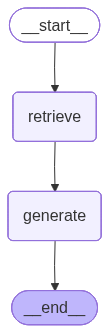

In [16]:
from IPython.display import Image, display

builder = StateGraph(State)

# Nodes
builder.add_node("retrieve", retrieve)
builder.add_node("generate", generate)

# Edges: START → retrieve → generate → END
builder.add_edge(START, "retrieve")
builder.add_edge("retrieve", "generate")
builder.add_edge("generate", END)

# Compile
graph = builder.compile()

# Visualise
display(Image(graph.get_graph().draw_mermaid_png()))

## Example Run

Let's try to look for this painting 

https://miamiuniversityartmuseum.omeka.net/items/show/1969

In [17]:
question = {"question":" Are there any paul cadmus paintings in the collection?"}
response = graph.invoke(question)
print(response["generation"].content)

---RETRIEVE---
{'id': '2009.13', 'title': 'The Guitarist', 'creator': 'Paul Cadmus', 'date': '1969', 'medium': None, 'format': 'Painting', 'subject': 'Modern & Contemporary-Paintings-20th C. & Later', 'donor': 'Bequest of Robert E. White, Jr.', 'citation': 'Paul Cadmus, “The Guitarist,”Richard and Carole Cocks Art Museum at Miami University, accessed July 6, 2025,https://miamiuniversityartmuseum.omeka.net/items/show/1969.', 'tags': [], 'collection_link': 'https://miamiuniversityartmuseum.omeka.net/items/show/1969'}
---GENERATE---
Yes, there is a Paul Cadmus painting in our collection. The painting is titled "The Guitarist" and was created in 1969. It features a man seated in his underwear playing the guitar in a room with a shelf and other objects.


In [18]:
question = {"question":"Are there any artworks that are about a person playing a stringed instrument"}
response = graph.invoke(question)
print(response["generation"].content)

---RETRIEVE---
{'id': '2009.13', 'title': 'The Guitarist', 'creator': 'Paul Cadmus', 'date': '1969', 'medium': None, 'format': 'Painting', 'subject': 'Modern & Contemporary-Paintings-20th C. & Later', 'donor': 'Bequest of Robert E. White, Jr.', 'citation': 'Paul Cadmus, “The Guitarist,”Richard and Carole Cocks Art Museum at Miami University, accessed July 6, 2025,https://miamiuniversityartmuseum.omeka.net/items/show/1969.', 'tags': [], 'collection_link': 'https://miamiuniversityartmuseum.omeka.net/items/show/1969'}
---GENERATE---
Yes, there are several artworks in our collection that feature a person playing a stringed instrument. Specifically, "The Guitarist" by Paul Cadmus depicts a man playing the guitar, while "Violin Player" by William Verplanck Birney shows a man playing the violin. Additionally, "Lady with a Lute" by Hugo Ballin features a seated lady playing the lute.


## SQL + Vector Hybrid Retrieval

Not every question needs semantic search. Some are better answered by exact SQL queries.

- **"How many paintings are in the collection?"** → SQL is faster and exact
- **"Art about loneliness and solitude"** → Vector captures semantic meaning

We'll build a **routing agent** that uses the LLM to classify each question and pick the right retrieval path.

In [19]:
# Load the same art data into an in-memory SQLite database
conn = sqlite3.connect(":memory:")
cur = conn.cursor()
cur.execute("""
    CREATE TABLE artworks (
        title TEXT, identifier TEXT, subject TEXT, description TEXT,
        creator TEXT, format TEXT, date TEXT, medium TEXT, donor TEXT
    )
""")
for art in data:
    cur.execute(
        "INSERT INTO artworks VALUES (?,?,?,?,?,?,?,?,?)",
        tuple(art.get(k) for k in
              ["Title","Identifier","Subject","Description","Creator","Format","Date","Medium","Donor"])
    )
conn.commit()
print(f"Loaded {cur.execute('SELECT COUNT(*) FROM artworks').fetchone()[0]} artworks into SQLite")

Loaded 2333 artworks into SQLite


In [20]:
# Quick sanity check — SQL works on the structured fields
cur.execute("SELECT title, creator, date FROM artworks WHERE creator LIKE '%Cadmus%'")
cur.fetchall()

[('The Guitarist', 'Paul Cadmus', '1969')]

### Adding a Router

We'll add a **router node** to the graph that classifies the user's question:
- If the question is about specific structured fields (creator, date, format, subject) → route to **SQL**
- If the question is about themes, moods, or visual descriptions → route to **vector search**

The LLM itself decides which path to take.

In [ ]:
def route_question(state):
    """Use the LLM to classify the query as sql or vector."""
    router_prompt = """You are a router for an art museum database. Given a user question, decide the retrieval method.

    Return "sql" if the question asks for specific structured data like:
    - A specific artist/creator name
    - A specific date or time period
    - A count or list filtered by exact fields (format, subject, donor)

    Return "vector" if the question is about:
    - Themes, moods, or abstract concepts
    - Visual descriptions or artistic style
    - Anything requiring semantic understanding

    Respond with ONLY "sql" or "vector".

    Question: {question}"""
    #----#
    result = llm.invoke([HumanMessage(content=router_prompt.format(question=state["question"]))])
    route = result.content.strip().lower()
    if route not in ("sql", "vector"):
        route = "vector"  # default fallback
    print(f"---ROUTE: {route}---")
    return {"route": route}

In [22]:
def sql_retrieve(state):
    """Generate and execute a SQL query against the artworks table."""
    print("---SQL RETRIEVE---")
    sql_prompt = """You are a SQL assistant. Given a user question about an art museum collection,
write a SQLite SELECT query against this table:

artworks(title, identifier, subject, description, creator, format, date, medium, donor)

Return ONLY the SQL query, nothing else.

Question: {question}"""
    result = llm.invoke([HumanMessage(content=sql_prompt.format(question=state["question"]))])
    query = result.content.strip().strip("`").replace("sql\n", "").strip()
    print(f"SQL: {query}")
    try:
        rows = cur.execute(query).fetchall()
        cols = [desc[0] for desc in cur.description]
        docs_text = "\n".join(
            ", ".join(f"{c}: {v}" for c, v in zip(cols, row)) for row in rows[:10]
        )
    except Exception as e:
        docs_text = f"SQL error: {e}"
    return {"documents": [Document(page_content=docs_text)]}

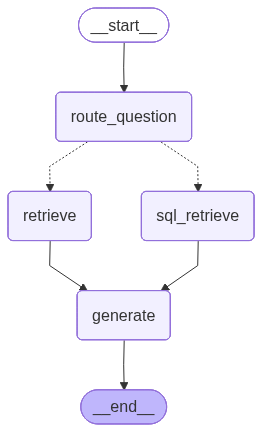

In [36]:
def decide_route(state):
    return "sql_retrieve" if state["route"] == "sql" else "retrieve"

builder = StateGraph(State)
builder.add_node("route_question", route_question)
builder.add_node("retrieve", retrieve)
builder.add_node("sql_retrieve", sql_retrieve)
builder.add_node("generate", generate)

builder.add_edge(START, "route_question")
builder.add_conditional_edges(
    "route_question",
    decide_route,
    {"sql_retrieve": "sql_retrieve", "retrieve": "retrieve"}
)
builder.add_edge("retrieve", "generate")
builder.add_edge("sql_retrieve", "generate")
builder.add_edge("generate", END)

routing_graph = builder.compile()
display(Image(routing_graph.get_graph().draw_mermaid_png()))

### Test: SQL-routed query

In [39]:
response = routing_graph.invoke({"question": "How many objects in total are in the collection?"})
print(response["generation"].content)

---ROUTE: sql---
---SQL RETRIEVE---
SQL: SELECT COUNT(*) FROM artworks;
---GENERATE---
Based on the provided context, COUNT(*): 2333, I can confidently answer that there are a total of 2,333 objects in the collection. This count includes all types of objects, from paintings to sculptures to artifacts, and represents the entire scope of the museum's holdings.


In [40]:
response = routing_graph.invoke({"question": "How many objects were donated by the same donor?"})
print(response["generation"].content)

---ROUTE: sql---
---SQL RETRIEVE---
SQL: SELECT COUNT(*) 
FROM artworks 
GROUP BY donor 
HAVING COUNT(donor) > 1;
---GENERATE---
Based on the provided context, it appears that there are multiple counts of different numbers. However, since all the counts are unrelated to donors or donations, I must conclude that the question cannot be answered definitively using this information alone.

In other words, without additional context or specific data about donations, it is impossible to determine how many objects were donated by the same donor.

Therefore, my answer would be: "Insufficient information available to provide a definitive answer."


### Test: Vector-routed query

In [38]:
response = routing_graph.invoke({"question": "Art that depicts loneliness or solitude"})
print(response["generation"].content)

---ROUTE: vector---
---RETRIEVE---
{'id': '2024.18', 'title': 'Desolate', 'creator': 'Claes Oldenburg (American, b. Sweden 1929)', 'date': '1972', 'medium': 'Offset lithograph process on paper with mechanical tints', 'format': 'PrintImage Size: 9 3/4 inches x 8 inches', 'subject': 'Graphic Arts-Prints', 'donor': "Gift of Jeffrey L. Horrell '75 and Rodney F. Rose", 'citation': 'Claes Oldenburg (American, b. Sweden 1929), “Desolate,”Richard and Carole Cocks Art Museum at Miami University, accessed July 6, 2025,https://miamiuniversityartmuseum.omeka.net/items/show/20706.', 'tags': ['20th Century', 'African Oceanic and New World Cultures', 'African Oceanic and New World Cultures-North America', 'American', 'Chair', 'Claes Oldenburg', 'Couch', 'Desolate', 'European', 'Graphic Arts', 'Graphic Arts-Prints', 'Lithograph', 'Mechanical tints', 'North American', 'Paper', 'Print', 'Sofa', 'Sweden', 'United States'], 'collection_link': 'https://miamiuniversityartmuseum.omeka.net/items/show/20706'}


## MCP (Model Context Protocol) Example